In [1]:
%matplotlib inline
from IPython.display import display, Markdown
import math
import re
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/home/dn/.tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import torch

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})



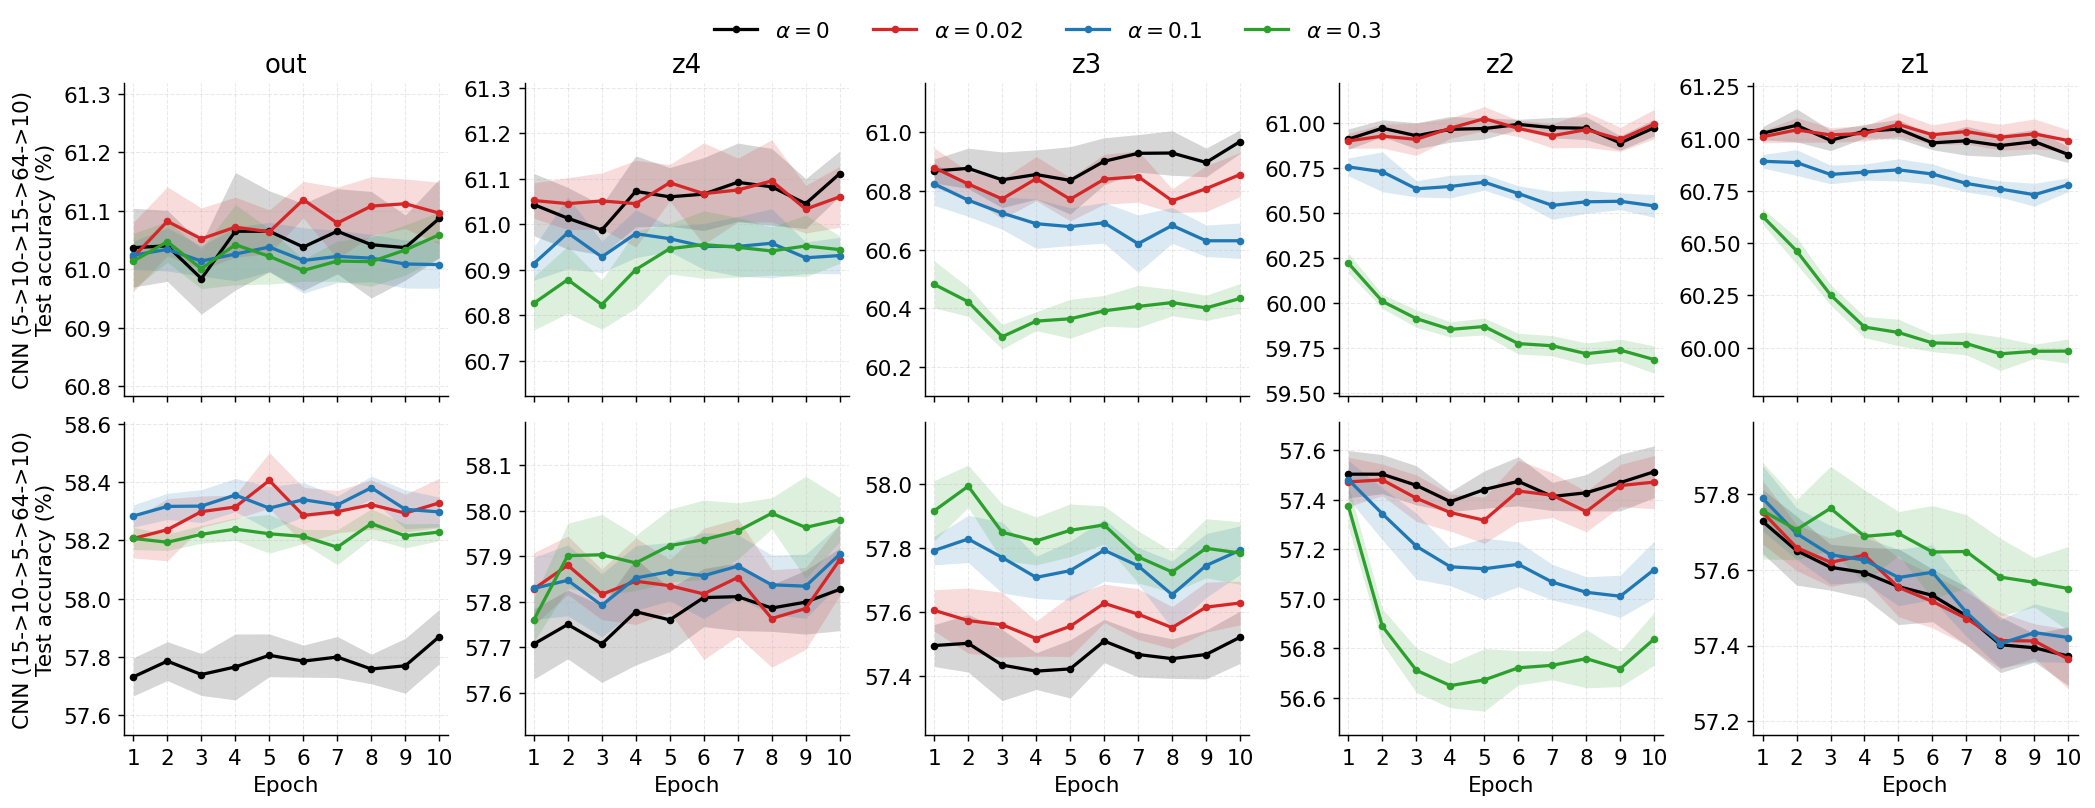

,model,recons_key,alpha,epoch,mean,std,n,sem,ci95
0,CNN (15->10->5->64->10),recons_out,0.0,1,57.732,0.091506,10,0.028937,0.065459
1,CNN (15->10->5->64->10),recons_out,0.0,2,57.786,0.093238,10,0.029484,0.066698
2,CNN (15->10->5->64->10),recons_out,0.0,3,57.740,0.100554,10,0.031798,0.071932
3,CNN (15->10->5->64->10),recons_out,0.0,4,57.766,0.158198,10,0.050027,0.113168
4,CNN (15->10->5->64->10),recons_out,0.0,5,57.806,0.102654,10,0.032462,0.073434


In [4]:
""" 画l两行折线图，第一行是simplecnn_ci10_v1的实验结果v1_data_file, 第二行是v3_data_file, 每一列是get_recons_name对应的特征图位置
以epoch为横坐标，testacc为纵坐标，分别画alpha=[0, 0.1, 0.02, 0.3]的四条折线，并在周围用相同颜色不同透明度高亮出95%置信区间
要求清晰美观，谢谢！"""
v4_data_file = "/data/dn/FRTP_revision1/imagecls/logs/cifar10/ci10_simplecnnv4_relu_e75_0.6102_10e.pt"
v5_data_file = "/data/dn/FRTP_revision1/imagecls/logs/cifar10/ci10_simplecnnv5_relu_e30_0.5813_10e.pt"
models = ["CNN (5->10->15->64->10)", "CNN (15->10->5->64->10)"]
baselines = [61.02, 58.13]
baselines = []
ALPHAS_TO_PLOT = [0,0.02, 0.1, 0.3]
RECONS_ORDER = ["recons_out", "recons_z4", "recons_z3", "recons_z2", "recons_z1"]
RECONS_LABELS = {
    "recons_out": "out",
    "recons_z4": "z4",
    "recons_z3": "z3",
    "recons_z2": "z2",
    "recons_z1": "z1",
}

def load_results(data_file):
    try:
        return torch.load(data_file, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(data_file, map_location="cpu")

def score_to_float(score):
    if isinstance(score, dict):
        for key in ("overall_acc", "testacc", "test_acc", "acc"):
            if key in score:
                return float(score[key])
        raise KeyError(f"Cannot find accuracy key in score dict: {score.keys()}")
    return float(score)

def results_to_epoch_df(data_file, model_label):
    records = []
    for rec in load_results(data_file):
        alpha = float(rec["alpha"])
        if not any(np.isclose(alpha, a) for a in ALPHAS_TO_PLOT):
            continue
        recons_key = rec.get("recons_key")
        if recons_key not in RECONS_ORDER:
            continue
        for epoch_idx, score in enumerate(rec["test_acc_ls"], start=1):
            records.append({
                "model": model_label,
                "alpha": alpha,
                "recons_key": recons_key,
                "seed": rec.get("seed", np.nan),
                "epoch": epoch_idx,
                "testacc": score_to_float(score) * 100,
            })
    return pd.DataFrame.from_records(records)

raw_df = pd.concat([
    results_to_epoch_df(v4_data_file, models[0]),
    results_to_epoch_df(v5_data_file, models[1]),
], ignore_index=True)

summary_df = (
    raw_df
    .groupby(["model", "recons_key", "alpha", "epoch"], as_index=False)
    .agg(mean=("testacc", "mean"), std=("testacc", "std"), n=("testacc", "count"))
)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["n"])
summary_df["ci95"] = stats.t.ppf(0.975, summary_df["n"] - 1) * summary_df["sem"]
summary_df.loc[summary_df["n"] <= 1, "ci95"] = 0.0

present_recons = [rk for rk in RECONS_ORDER if rk in set(summary_df["recons_key"])]
colors = {
    0: "#000000",
    0.1: "#1f77b4",
    0.02: "#d62728",
    0.3: "#2ca02c",
}

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(present_recons),
    figsize=(3.2 * len(present_recons), 5.8),
    sharex=True,
    sharey=False,
    constrained_layout=True,
)

for row_idx, model in enumerate(models):
    for col_idx, recons_key in enumerate(present_recons):
        ax = axes[row_idx, col_idx] if len(models) > 1 else axes[col_idx]
        
        for alpha in ALPHAS_TO_PLOT:
            sub = summary_df[
                (summary_df["model"] == model)
                & (summary_df["recons_key"] == recons_key)
                & np.isclose(summary_df["alpha"], alpha)
            ].sort_values("epoch")
            if sub.empty:
                continue
            x = sub["epoch"].to_numpy(dtype=float)
            y = sub["mean"].to_numpy(dtype=float)
            ci = sub["ci95"].to_numpy(dtype=float)
            color = colors[alpha]
            ax.plot(x, y, marker="o", markersize=3.2, linewidth=1.8, color=color, label=fr"$\alpha={alpha:g}$")
            ax.fill_between(x, y - ci, y + ci, color=color, alpha=0.16, linewidth=0)
        if baselines:
            ax.plot(x, [baselines[row_idx]]*len(x), color="black", linestyle="--", label="baseline")

        if row_idx == 0:
            ax.set_title(RECONS_LABELS.get(recons_key, recons_key))
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nTest accuracy (%)")
        if row_idx == len(models) - 1:
            ax.set_xlabel("Epoch")
        y_scope = summary_df[(summary_df["model"] == model) & (summary_df["recons_key"] == recons_key)]
        if not y_scope.empty:
            y_lower = y_scope["mean"].min()
            y_upper = y_scope["mean"].max()
            ax.set_ylim(max(0, y_lower - 0.2), min(100, y_upper + 0.2))
        ax.set_xticks(range(1, 11))
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.28)
        ax.margins(x=0.03)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(ALPHAS_TO_PLOT)+1, frameon=False, bbox_to_anchor=(0.5, 1.06))
# fig.suptitle("CIFAR-10 SimpleCNN FRTP: test accuracy by reconstruction layer", y=1.12, fontsize=14, fontweight="bold")
plt.show()

display(summary_df.head())